# Plotting the CFU counts per media, process, dilution


In [11]:
"""
Shared plot style helper for thesis figures.
Import apply_style() and CM_TO_INCH in your plotting scripts.
"""
import matplotlib.pyplot as plt


CM_TO_INCH = 1 / 2.54
PLOT_WIDTH_CM = 15
PLOT_HEIGHT_CM = 10
DPI = 300
 
 
def apply_style(ax, fig, title, xlabel, ylabel):
    """Apply the standard thesis plot style to an existing ax/fig."""
    ax.set_title(title, fontsize=14, fontweight='normal', pad=15)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='normal')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='normal')
 
    ax.tick_params(axis='both', which='major', labelsize=11, width=1, length=5)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1, length=3)
 
    leg = ax.legend(
        loc='upper right',
        prop={'size': 11, 'weight': 'normal'},
        frameon=True,
        framealpha=0.8,
        edgecolor='gray',
        borderpad=0.8,
    )
    leg.get_frame().set_linewidth(1.0)
 
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
 
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)
    plt.tight_layout()
 
 
def new_fig():
    """Create a fig/ax pair at the standard thesis figure size/dpi."""
    return plt.subplots(figsize=(PLOT_WIDTH_CM * CM_TO_INCH, PLOT_HEIGHT_CM * CM_TO_INCH), dpi=DPI)
 
 
def compute_zero_floor(values, factor=0.5):
    """Return a y-position to plot true zeros at on a log axis.
 
    Log scale can't show 0, so zeros are placed just below the smallest
    non-zero value in `values` (at `factor` times that value) instead of
    being silently dropped by matplotlib.
    """
    nonzero = values[values > 0]
    if len(nonzero) == 0:
        return 1e-3
    return nonzero.min() * factor
 


## Loading the data

In [12]:
"""
Load the CFU results data (4th sheet) from Sample1-2_results_CFUs.xlsx.
"""
import pandas as pd


DILUTION_ORDER = ['D2', 'D1', 'D0', 'D0c', 'D-1', 'D-2', 'D-3']
 
 
def load_cfu_data(filepath, sheet_index=3):
    """Read the CFU sheet and cast categorical columns to string dtype."""
    df = pd.read_excel(filepath, sheet_name=sheet_index)
    for col in ['Dilution', 'Media', 'Replicate', 'Process']:
        df[col] = df[col].astype(str)
    return df
 
 
def sorted_dilutions(series, order=DILUTION_ORDER):
    """Order dilution labels per the fixed thesis convention.
 
    Values in `order` that are present in `series` come first, in that order;
    any values present in `series` but not in `order` are appended alphabetically.
    """
    present = set(series.unique())
    ordered = [d for d in order if d in present]
    extra = sorted(present - set(order))
    return ordered + extra
 


## Testing different media

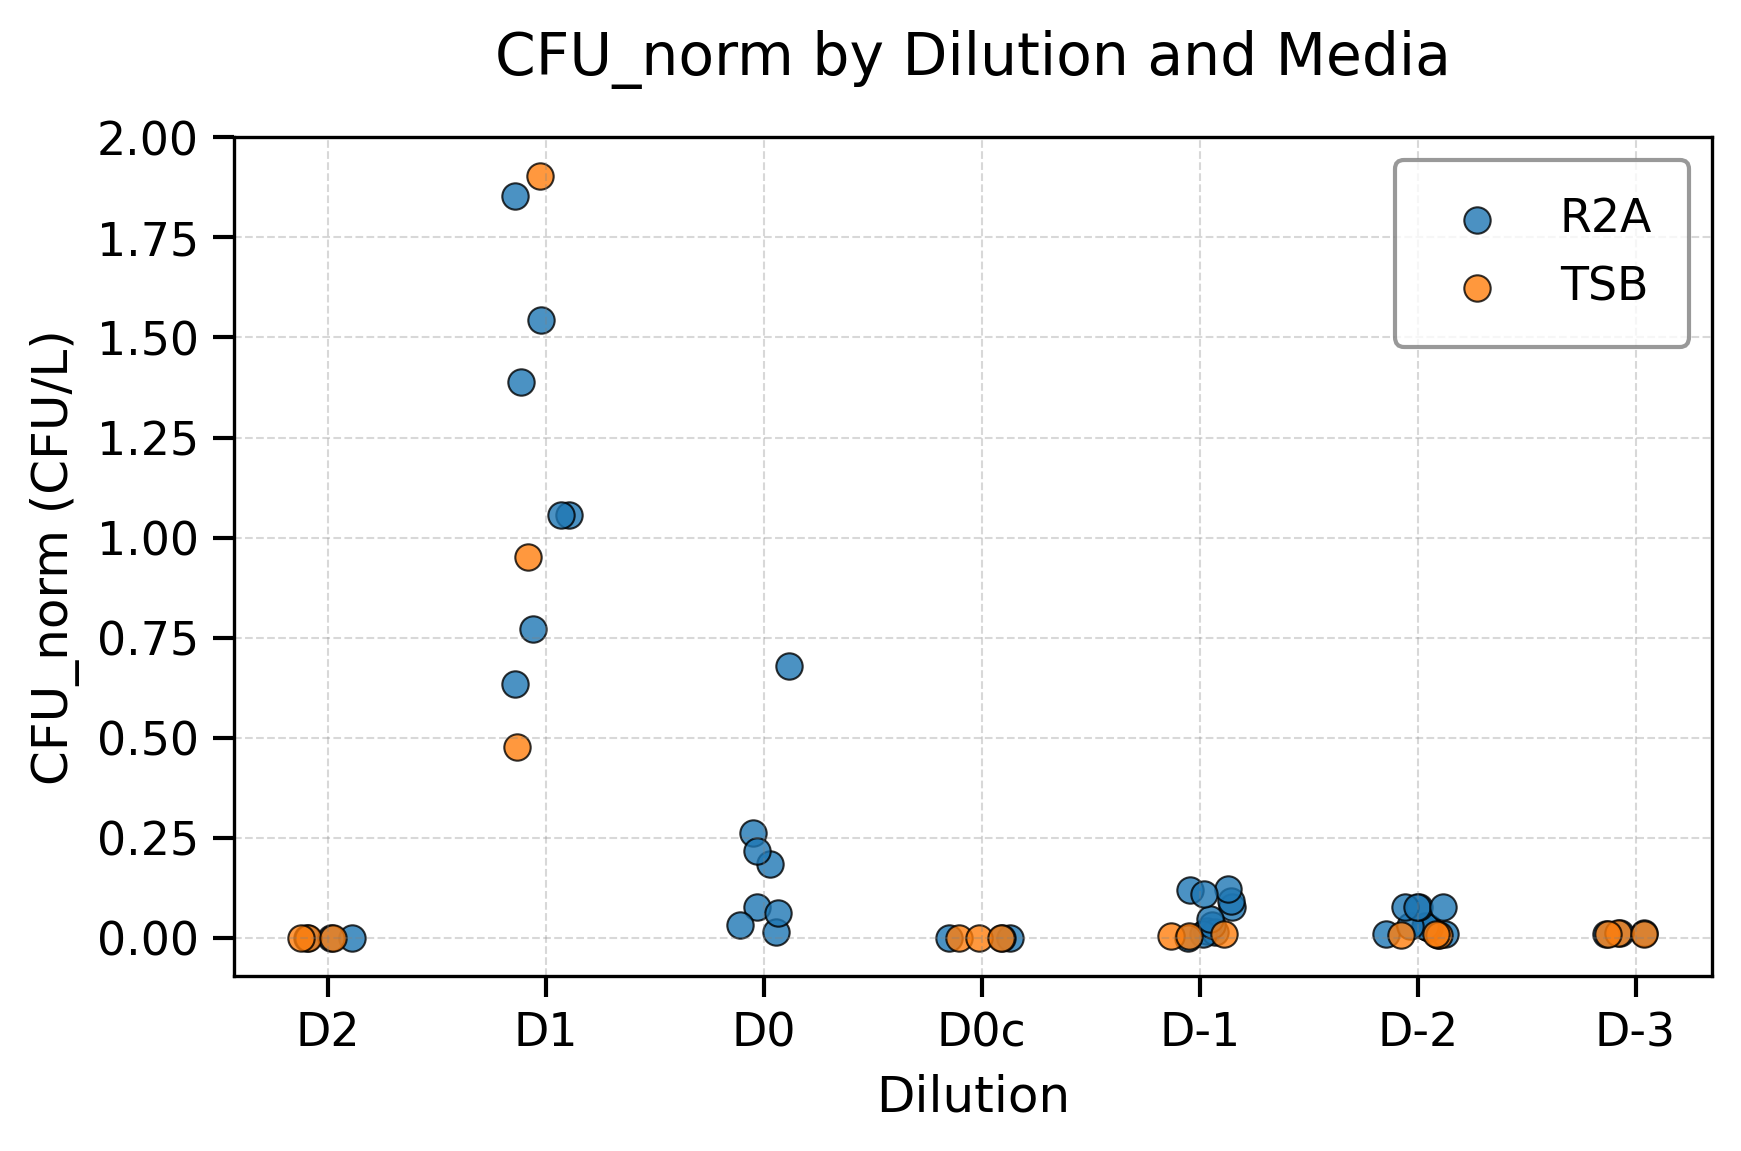

In [13]:
"""
Plot CFU_norm vs Dilution, one color per Media.
"""
#import numpy as np
#import matplotlib.pyplot as plt

#from load_cfu_data import load_cfu_data, sorted_dilutions
#from plot_style import apply_style, new_fig

JITTER_WIDTH = 0.15
RNG_SEED = 0


def plot_cfu_by_media(df, save_path=None):
    dilution_order = sorted_dilutions(df['Dilution'])
    x_pos = {d: i for i, d in enumerate(dilution_order)}

    medias = sorted(df['Media'].unique())
    cmap = plt.get_cmap('tab10')
    colors = {m: cmap(i % 10) for i, m in enumerate(medias)}

    fig, ax = new_fig()
    rng = np.random.default_rng(RNG_SEED)

    for media in medias:
        sub = df[df['Media'] == media]
        x = sub['Dilution'].map(x_pos).to_numpy(dtype=float)
        x_jittered = x + rng.uniform(-JITTER_WIDTH, JITTER_WIDTH, size=len(x))
        ax.scatter(
            x_jittered, sub['CFU_norm'],
            label=media, color=colors[media],
            s=40, alpha=0.8, edgecolor='black', linewidth=0.5,
        )

    ax.set_xticks(range(len(dilution_order)))
    ax.set_xticklabels(dilution_order)
    apply_style(ax, fig, 'CFU_norm by Dilution and Media', 'Dilution', 'CFU_norm (CFU/L)')

    if save_path:
        fig.savefig(save_path, dpi=300, transparent=True)
    plt.show()
    return fig, ax


if __name__ == '__main__':
    df = load_cfu_data("Sample1-2_results_CFUs.xlsx")
    plot_cfu_by_media(df)

### Log scale

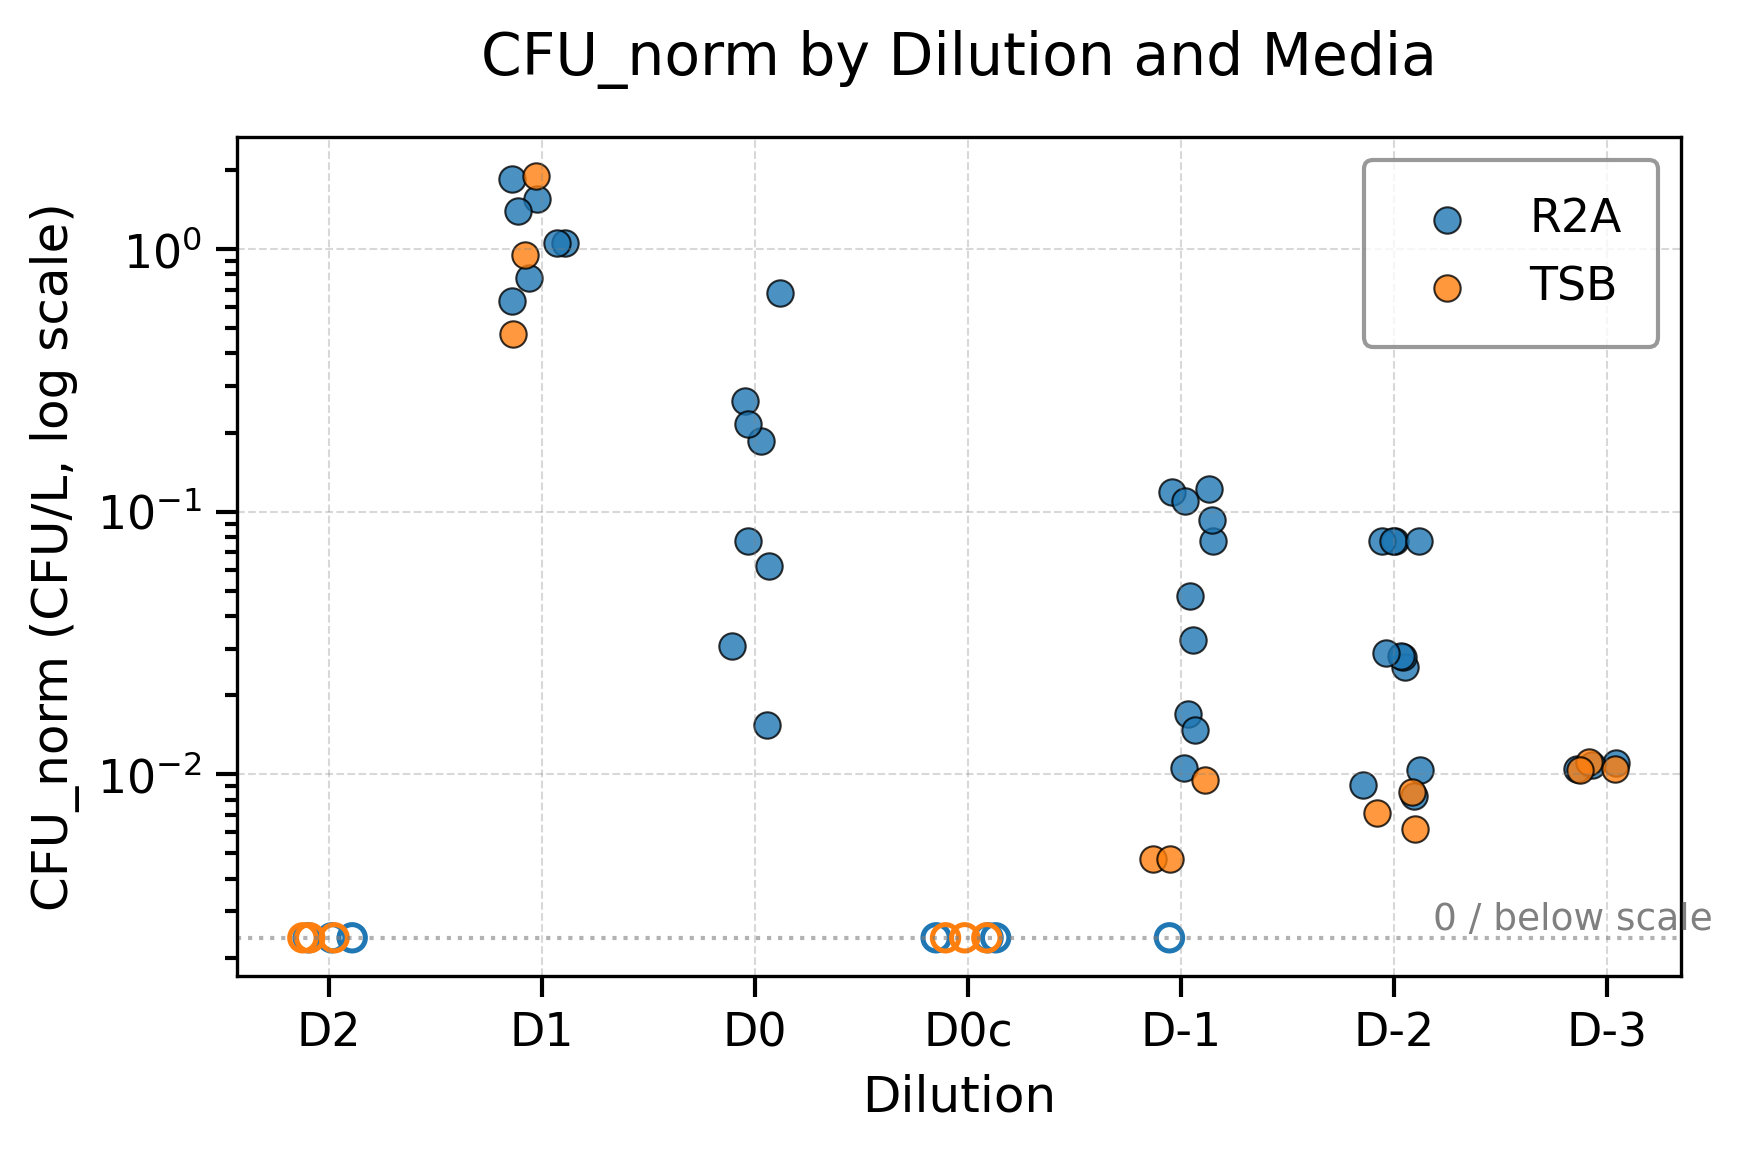

In [14]:

JITTER_WIDTH = 0.15
RNG_SEED = 0
import matplotlib.pyplot as plt
 
 
def plot_cfu_by_media(df, log_scale=True, save_path=None):
    dilution_order = sorted_dilutions(df['Dilution'])
    x_pos = {d: i for i, d in enumerate(dilution_order)}
 
    medias = sorted(df['Media'].unique())
    cmap = plt.get_cmap('tab10')
    colors = {m: cmap(i % 10) for i, m in enumerate(medias)}
 
    zero_floor = compute_zero_floor(df['CFU_norm']) if log_scale else None
 
    fig, ax = new_fig()
    rng = np.random.default_rng(RNG_SEED)
 
    for media in medias:
        sub = df[df['Media'] == media]
        x = sub['Dilution'].map(x_pos).to_numpy(dtype=float)
        x_jittered = x + rng.uniform(-JITTER_WIDTH, JITTER_WIDTH, size=len(x))
 
        if log_scale:
            is_zero = (sub['CFU_norm'] <= 0).to_numpy()
        else:
            is_zero = np.zeros(len(sub), dtype=bool)
        y = sub['CFU_norm'].to_numpy(dtype=float).copy()
        if log_scale:
            y[is_zero] = zero_floor
 
        # real, non-zero measurements: filled markers
        ax.scatter(
            x_jittered[~is_zero], y[~is_zero],
            label=media, color=colors[media],
            s=40, alpha=0.8, edgecolor='black', linewidth=0.5,
        )
        # true zeros: open markers at the floor, no duplicate legend entry
        if is_zero.any():
            ax.scatter(
                x_jittered[is_zero], y[is_zero],
                color='none', edgecolor=colors[media],
                s=40, linewidth=1.2,
            )
 
    ax.set_xticks(range(len(dilution_order)))
    ax.set_xticklabels(dilution_order)
    if log_scale:
        ax.set_yscale('log')
        ax.axhline(zero_floor, color='gray', linestyle=':', linewidth=1, alpha=0.6)
        ax.text(len(dilution_order) - 0.5, zero_floor, '0 / below scale',
                fontsize=9, color='gray', va='bottom', ha='right')
    ylabel = 'CFU_norm (CFU/L, log scale)' if log_scale else 'CFU_norm (CFU/L)'
    apply_style(ax, fig, 'CFU_norm by Dilution and Media', 'Dilution', ylabel)
 
    if save_path:
        fig.savefig(save_path, dpi=300, transparent=True)
    plt.show()
    return fig, ax
 
 
if __name__ == '__main__':
    df = load_cfu_data("Sample1-2_results_CFUs.xlsx")
    plot_cfu_by_media(df)
 


## Testing different processing

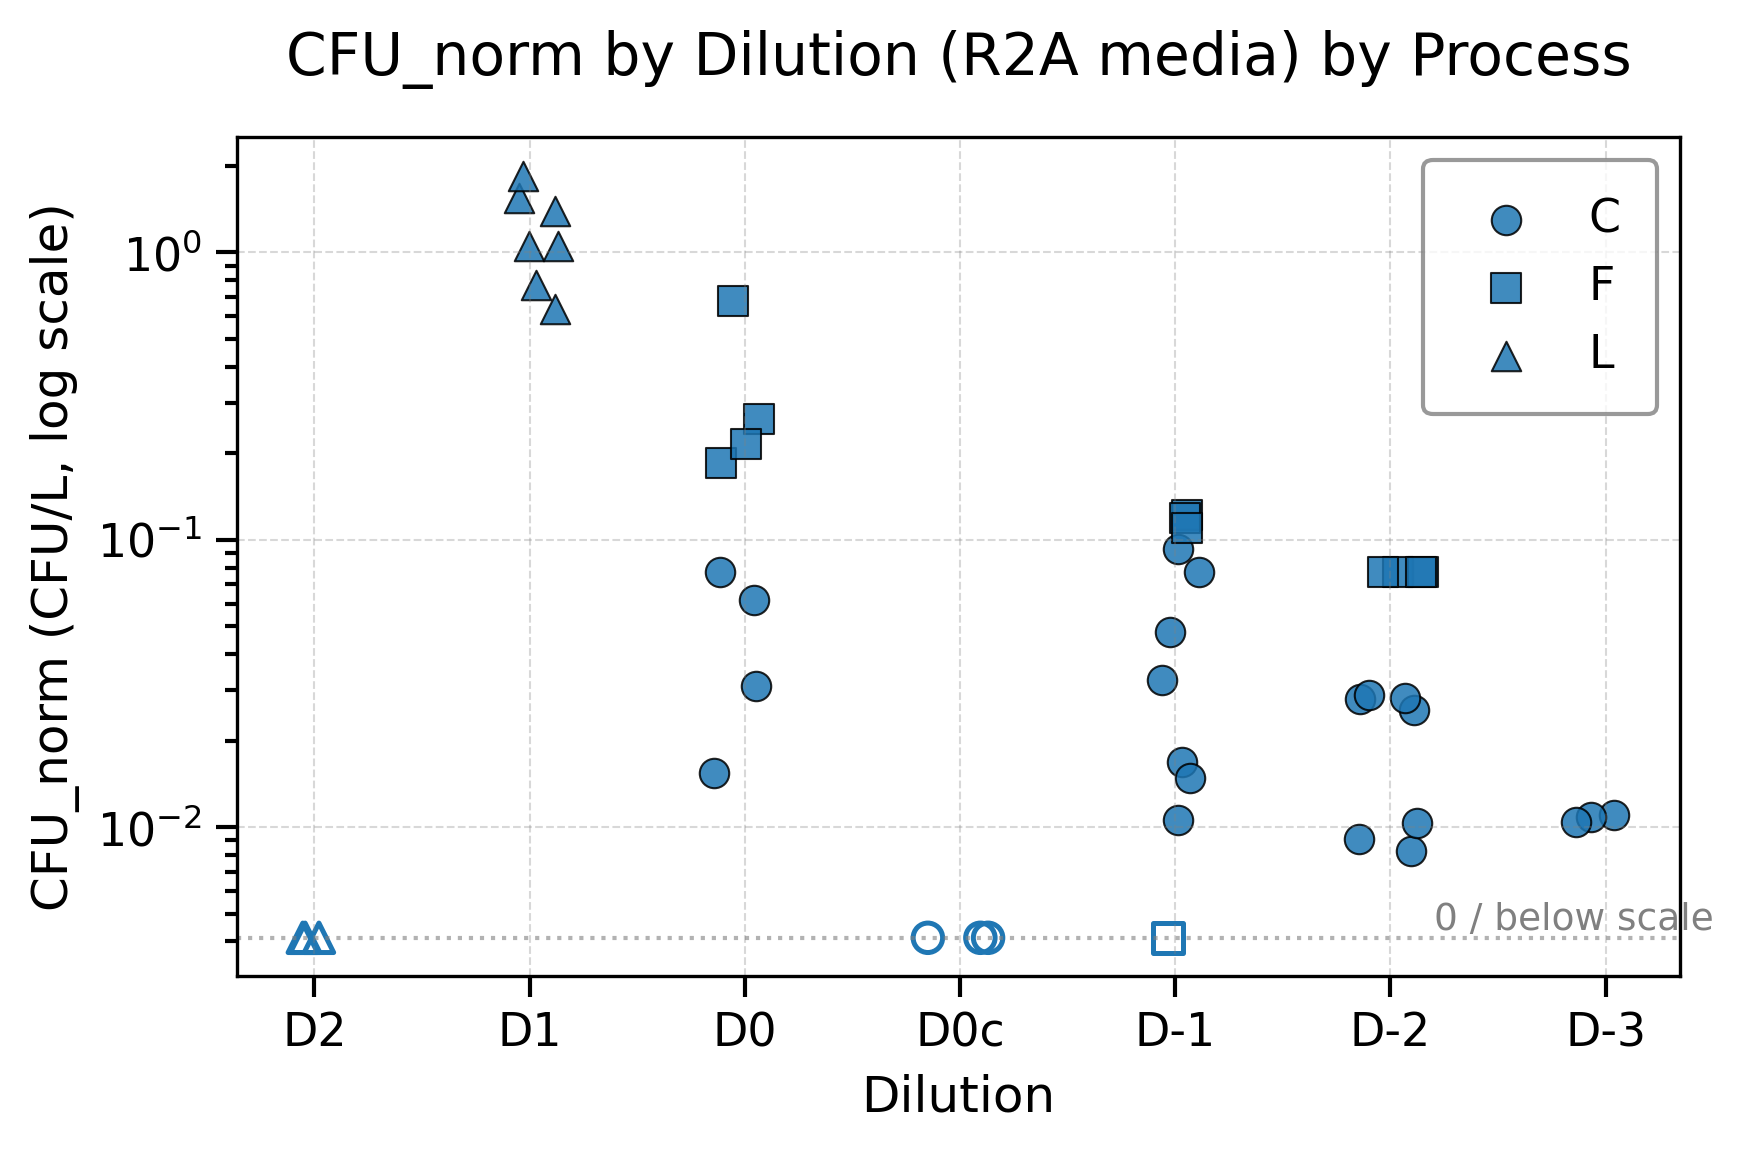

In [17]:
"""
Plot CFU_norm vs Dilution, R2A media only, one marker shape per Process.
"""
#import numpy as np

#from load_cfu_data import load_cfu_data, sorted_dilutions
#from plot_style import apply_style, new_fig


MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
POINT_COLOR = '#1f77b4'
JITTER_WIDTH = 0.15
RNG_SEED = 0
 
 
def plot_cfu_r2a_by_process(df, media='R2A', log_scale=True, save_path=None):
    df_media = df[df['Media'] == media]
    dilution_order = sorted_dilutions(df_media['Dilution'])
    x_pos = {d: i for i, d in enumerate(dilution_order)}
 
    processes = sorted(df_media['Process'].unique())
    marker_map = {p: MARKERS[i % len(MARKERS)] for i, p in enumerate(processes)}
 
    zero_floor = compute_zero_floor(df_media['CFU_norm']) if log_scale else None
 
    fig, ax = new_fig()
    rng = np.random.default_rng(RNG_SEED)
 
    for process in processes:
        sub = df_media[df_media['Process'] == process]
        x = sub['Dilution'].map(x_pos).to_numpy(dtype=float)
        x_jittered = x + rng.uniform(-JITTER_WIDTH, JITTER_WIDTH, size=len(x))
 
        if log_scale:
            is_zero = (sub['CFU_norm'] <= 0).to_numpy()
        else:
            is_zero = np.zeros(len(sub), dtype=bool)
        y = sub['CFU_norm'].to_numpy(dtype=float).copy()
        if log_scale:
            y[is_zero] = zero_floor
 
        ax.scatter(
            x_jittered[~is_zero], y[~is_zero],
            label=process, marker=marker_map[process],
            s=50, alpha=0.85, color=POINT_COLOR, edgecolor='black', linewidth=0.5,
        )
        if is_zero.any():
            ax.scatter(
                x_jittered[is_zero], y[is_zero],
                marker=marker_map[process], color='none',
                edgecolor=POINT_COLOR, s=50, linewidth=1.2,
            )
 
    ax.set_xticks(range(len(dilution_order)))
    ax.set_xticklabels(dilution_order)
    if log_scale:
        ax.set_yscale('log')
        ax.axhline(zero_floor, color='gray', linestyle=':', linewidth=1, alpha=0.6)
        ax.text(len(dilution_order) - 0.5, zero_floor, '0 / below scale',
                fontsize=9, color='gray', va='bottom', ha='right')
    ylabel = 'CFU_norm (CFU/L, log scale)' if log_scale else 'CFU_norm (CFU/L)'
    apply_style(ax, fig, f'CFU_norm by Dilution ({media} media) by Process', 'Dilution', ylabel)
 
    if save_path:
        fig.savefig(save_path, dpi=300, transparent=True)
    plt.show()
    return fig, ax
 
 
if __name__ == '__main__':
    df = load_cfu_data("Sample1-2_results_CFUs.xlsx")
    plot_cfu_r2a_by_process(df)
 


In [ ]:

df = load_cfu_data("Sample1-2_results_CFUs.xlsx")

print("Media values:", df['Media'].unique())
df_r2a = df[df['Media'] == 'R2A']
print("Rows after R2A filter:", len(df_r2a))

print("Dilution values in data:", df_r2a['Dilution'].unique())
print("DILUTION_ORDER:", DILUTION_ORDER)
print("Matched order:", sorted_dilutions(df_r2a['Dilution']))

print("CFU_norm nulls:", df_r2a['CFU_norm'].isna().sum())
print(df_r2a[['Dilution', 'Process', 'CFU_norm']].head(10))

Media values: ['R2A' 'TSB']
Rows after R2B filter: 0
Dilution values in data: []
DILUTION_ORDER: ['D2', 'D1', 'D0', 'D0c', 'D-1', 'D-2', 'D-3']
Matched order: []
CFU_norm nulls: 0
Empty DataFrame
Columns: [Dilution, Process, CFU_norm]
Index: []
